In [28]:
# Look at simulations at a lower inverse Froude number

In [29]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps
from scipy.ndimage import binary_dilation

In [30]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [31]:
savefig=True

rot = False

dycore1 = 'CAM-SE'
res1 = 'se_ne60'
test_name_start1 = 'cam_6_4_100'
lev_no1 = 'ztop20km_L57_u20'
file_end1 = '.nc'

dycore2 = 'CAM-FV3'
res2 = 'fv3_C192'
test_name_start2 = 'cam_6_4_070_horiz_mount_flow'
lev_no2 = 'ztop20km_L57_u20'
file_end2 = '.regrid.0.5x0.5.aave.nc'

case1 = f'{test_name_start1}_{res1}_{lev_no1}'
case2 = f'{test_name_start2}_{res2}_{lev_no2}'

# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_with_rot{file_end1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_with_rot{file_end2}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_omega0{file_end1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_omega0{file_end2}'


In [32]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)

In [33]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 
lev = nc1['lev'][:]

print(np.size(lat), np.size(lon))

361 720


In [34]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

# Consistent lon lat ranges
lat_crop_up = 50.
lat_cent_down = -50.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 340.#280.
#lon_ticks = np.linspace(140, 280, 8)
lon_ticks = np.array([140,180,220,260, 300, 340])

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(401,)


In [35]:
# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [36]:
# Interpolations of U and T

U_field_vals1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_field_vals1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [37]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (U_field_vals1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (U_field_vals2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
T_field_vals1 = T_field_vals1 - T0
T_field_vals2 = T_field_vals2 - T0

In [38]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
T_max_crop1 = T_field_vals1[:,lon_max_inds]

U_max_crop2 = U_field_vals2[:,lon_max_inds]
T_max_crop2 = T_field_vals2[:,lon_max_inds]


In [39]:
# New method --- compute everywhere away from the orography.
# Mask the orography values to zero.
def exclude_mountain_neighbourhood(*fields, iterations=1):
    """
    Return copies of fields with the mountain and `iterations`
    surrounding grid cells masked as NaN.
    """
    fields = [
        np.ma.filled(np.ma.asarray(field, dtype=float), np.nan)
        for field in fields
    ]

    # Exclude any point masked as mountain in any model.
    mountain = np.logical_or.reduce([~np.isfinite(field) for field in fields])

    # Add one grid cell in every direction, including diagonals.
    exclude = binary_dilation(
        mountain,
        structure=np.ones((3, 3), dtype=bool),
        iterations=iterations
    )

    return [np.where(exclude, np.nan, field) for field in fields]

(
    T_stats1,
    T_stats2,
) = exclude_mountain_neighbourhood(
    T_field_vals1,
    T_field_vals2,
    iterations=1
)

(
    U_stats1,
    U_stats2,
) = exclude_mountain_neighbourhood(
    U_field_vals1,
    U_field_vals2,
    iterations=1
)

T_min1, T_max1 = np.nanmin(T_stats1), np.nanmax(T_stats1)
T_min2, T_max2 = np.nanmin(T_stats2), np.nanmax(T_stats2)

U_min1, U_max1 = np.nanmin(U_stats1), np.nanmax(U_stats1)
U_min2, U_max2 = np.nanmin(U_stats2), np.nanmax(U_stats2)

print(T_min1, T_max1)
print(f'a T min {np.min(T_max_crop1):.2f}, T max {np.max(T_max_crop1):.2f} \n')

print(T_min2, T_max2)
print(f'b T min {np.min(T_max_crop2):.2f}, T max {np.max(T_max_crop2):.2f} \n')


print(U_min1, U_max1)
print(f'a U min {np.min(U_max_crop1):.2f}, T max {np.max(U_max_crop1):.2f} \n')

print(U_min2, U_max2)
print(f'b U min {np.min(U_max_crop2):.2f}, T max {np.max(U_max_crop2):.2f} \n')

-2.5468541041411754 18.619277874848763
a T min -2.55, T max 13.81 

-2.829235195920319 19.022793199569037
b T min -2.83, T max 13.48 

-2.9808992783734736 2.355936421211972
a U min -2.91, T max 2.36 

-3.2054860410850576 2.373580131527648
b U min -2.42, T max 2.34 



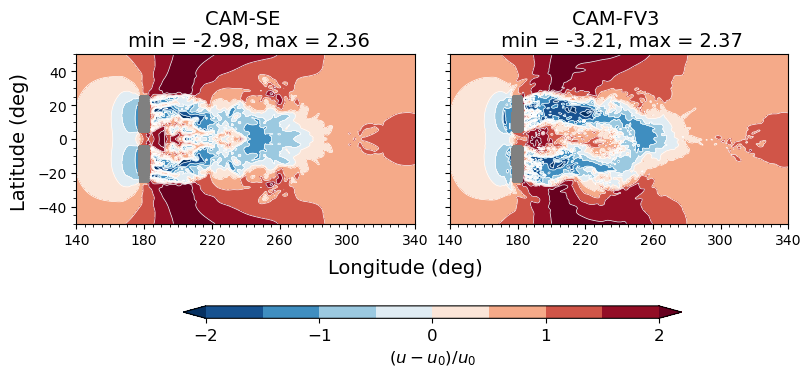

In [40]:
# Plot for U
U_cmap = matplotlib.cm.RdBu_r

if rot:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
else:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")
    
(ax1, ax2) = axes

# Consistent scales between with/without rotation
U_conts = np.linspace(-2.0, 2.0, 9)
U_tick_range = np.linspace(-2.0, 2.0, 5)
U_norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)


plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=U_norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=U_norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=U_norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=U_norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = U_tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'CAM-SE \n min = {U_min1:.2f}, max = {U_max1:.2f}', size=label_size)
ax2.set_title(f'CAM-FV3 \n min = {U_min2:.2f}, max = {U_max2:.2f}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size, y=0.35)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.14)

if savefig:
    if rot:
        plt.savefig('u20_figs/gap_with_rot_U.png', bbox_inches='tight')
    else:
        plt.savefig('u20_figs/gap_omega0_U.png', bbox_inches='tight')



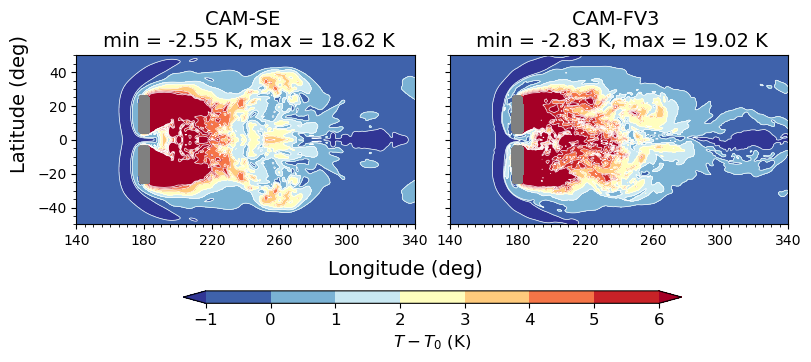

In [41]:
### T plot

T_cmap = copy.copy(matplotlib.cm.RdYlBu_r)
T_conts = np.linspace(-1, 6, 8)
T_norm = colors.Normalize(vmin=-1, vmax=6)
T_tick_range = np.linspace(-1, 6, 8)

fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")

(ax1, ax2) = axes
    
plot1 = ax1.contourf(LON, LAT, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=T_norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=T_norm, extend = 'both')

# If we want contours overlaid:
ax1.contour(LON, LAT, T_field_vals1, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=T_norm, extend = 'both')
ax2.contour(LON, LAT, T_field_vals2, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=T_norm, extend = 'both')

T_title = 'Temperature perturbation'
for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = T_tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'CAM-SE \n min = {T_min1:.2f} K, max = {T_max1:.2f} K', size=label_size)
ax2.set_title(f'CAM-FV3 \n min = {T_min2:.2f} K, max = {T_max2:.2f} K', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.15)

if savefig:
    if rot:
        plt.savefig('u20_figs/gap_with_rot_T.png', bbox_inches='tight')
    else:
        plt.savefig('u20_figs/gap_omega0_T.png', bbox_inches='tight')
        

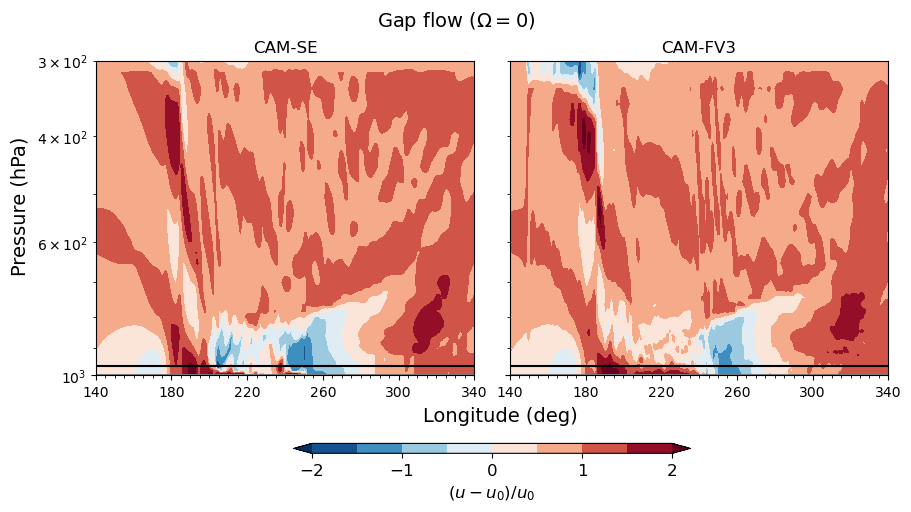

In [42]:
# What about cross section through the gap:
LONcross, LEV = np.meshgrid(lon_crop, lev)

eq_lat = 180

U_eq1 = (nc1['U'][t_idx, :, eq_lat, lon_inds] - u0)/u0
U_eq2 = (nc2['U'][t_idx, :, eq_lat, lon_inds] - u0)/u0

fig, axes = plt.subplots(1,2,figsize = (9,5), sharey=True, constrained_layout=True)
(ax1, ax2) = axes


plot1 = ax1.contourf(LONcross, LEV, U_eq1, levels = U_conts, cmap=U_cmap, norm=U_norm, extend = 'both')
plot2 = ax2.contourf(LONcross, LEV, U_eq2, levels = U_conts, cmap=U_cmap, norm=U_norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_facecolor("grey")

    ax.set_xticks(lon_ticks)

    ax.invert_yaxis()
    ax.set_yscale('log')
    ax.set_ylim([1000,300])

cb = plt.colorbar(plot2, ax=axes, ticks = U_tick_range, shrink=0.5, pad=0.12, aspect=40, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore1}')
ax2.set_title(f'{dycore2}')

# pressure at z=300m for the isothermal atmosphere.
p_300 = 965

ax1.plot(lon_crop, p_300*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, p_300*np.ones_like(lon_crop), c='k')

fig.supylabel('Pressure (hPa)', size=label_size, y=0.6)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.55, y=0.16)

if rot:
    fig.suptitle(r'Gap flow ($\Omega\neq0$)', size=14)
else:
    fig.suptitle(r'Gap flow ($\Omega=0$)', size=14)

In [43]:
# Examine the effect on asymmetry


T_asym1=0
T_asym2=0

eq_ind = 100
new_lon_inds = np.where((lon_crop <= 260) & (lon_crop >= 220))[0]


for i in np.arange(100):
    T_asym1 += np.nansum(np.abs(T_field_vals1[eq_ind+i, :] - T_field_vals1[eq_ind-i, :]))
    T_asym2 += np.nansum(np.abs(T_field_vals2[eq_ind+i, :] - T_field_vals2[eq_ind-i, :]))

T_asym1 /= (100*281)
T_asym2 /= (100*281)

print(T_asym1)
print(T_asym2)

0.0030003603629092054
0.6318044734022449


In [44]:
# Examine the impact on the locaiton of max T' in each hemisphere.
def find_hemisphere_max(field_vals, lon, lat, hemisphere,
                        lon_bounds=None):
    """
    Find the maximum field value in one hemisphere.

    Parameters
    ----------
    field_vals : 2-D array, shape (nlat, nlon)
        Temperature perturbation field.
    lon, lat : 1-D or 2-D arrays
        Longitude and latitude coordinates.
    hemisphere : {"north", "south"}
        Hemisphere in which to search.
    lon_bounds : tuple or None
        Optional (minimum_longitude, maximum_longitude) search range.
        For example, (190, 270) restricts the search to the lee region.

    Returns
    -------
    result : dict
        Maximum value, longitude, latitude, and array indices.
    """

    # Convert masked values to NaN
    field_vals = np.ma.filled(
        np.ma.asarray(field_vals, dtype=float), np.nan
    )

    # Construct 2-D coordinate arrays if lon and lat are 1-D
    if np.ndim(lon) == 1 and np.ndim(lat) == 1:
        LON, LAT = np.meshgrid(lon, lat)
    else:
        LON = np.asarray(lon)
        LAT = np.asarray(lat)

    if field_vals.shape != LON.shape or field_vals.shape != LAT.shape:
        raise ValueError(
            f"Incompatible shapes: field={field_vals.shape}, "
            f"LON={LON.shape}, LAT={LAT.shape}"
        )

    hemisphere = hemisphere.lower()

    if hemisphere in ("north", "northern", "nh"):
        search_mask = LAT > 0
    elif hemisphere in ("south", "southern", "sh"):
        search_mask = LAT < 0
    else:
        raise ValueError("hemisphere must be 'north' or 'south'")

    # Optionally restrict the search to the downstream/lee region
    if lon_bounds is not None:
        lon_min, lon_max = lon_bounds

        if lon_min <= lon_max:
            search_mask &= (LON >= lon_min) & (LON <= lon_max)
        else:
            # Supports a longitude interval crossing 0 degrees
            search_mask &= (LON >= lon_min) | (LON <= lon_max)

    search_mask &= np.isfinite(field_vals)

    if not np.any(search_mask):
        raise ValueError("No finite field values found in the search region.")

    # Points outside the selected region cannot be chosen
    search_field = np.where(search_mask, field_vals, np.nan)

    row, col = np.unravel_index(
        np.nanargmax(search_field),
        search_field.shape
    )

    return {
        "value": field_vals[row, col],
        "lon": LON[row, col],
        "lat": LAT[row, col],
        "row": row,
        "col": col,
    }



In [45]:
# Restrict the search to the lee side so that maxima near the
# topography are not accidentally identified as vortex centers.
# Use lon_bounds=None if you want to search the entire plotted domain.
lee_lon_bounds = (190, 270)

results = {
    "mpas def north": find_hemisphere_max(
        T_field_vals1, lon_crop, lat_crop, "north", lee_lon_bounds
    ),
    "mpas def south": find_hemisphere_max(
        T_field_vals1, lon_crop, lat_crop, "south", lee_lon_bounds
    ),
    "mpas less diff north": find_hemisphere_max(
        T_field_vals2, lon_crop, lat_crop, "north", lee_lon_bounds
    ),
    "mpas less diff south": find_hemisphere_max(
        T_field_vals2, lon_crop, lat_crop, "south", lee_lon_bounds
    ),
}

for name, result in results.items():
    print(
        f"{name:12s}: "
        f"max T' = {result['value']:.3f} K, "
        f"lon = {result['lon']:.3f} deg, "
        f"lat = {result['lat']:.3f} deg, "
        f"index = ({result['row']}, {result['col']})"
    )

mpas def north: max T' = 13.810 K, lon = 190.000 deg, lat = 8.500 deg, index = (117, 100)
mpas def south: max T' = 13.810 K, lon = 190.000 deg, lat = -8.500 deg, index = (83, 100)
mpas less diff north: max T' = 11.680 K, lon = 193.500 deg, lat = 1.500 deg, index = (103, 107)
mpas less diff south: max T' = 13.480 K, lon = 193.000 deg, lat = -3.500 deg, index = (93, 106)
